# 📊 ShopMind AI — Fase 1: EDA & Limpieza de Datos

Dataset: [Brazilian E-Commerce Public Dataset by Olist](https://www.kaggle.com/datasets/olistbr/brazilian-ecommerce)

**Objetivos de esta fase:**
- Entender la estructura del dataset
- Analizar comportamiento de usuarios (frecuencia, categorías, ratings)
- Generar el dataset procesado que alimentará el RAG


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

sns.set_theme(style='whitegrid')
pd.set_option('display.max_columns', None)

RAW_PATH = '../data/raw/'
PROCESSED_PATH = '../data/processed/'
os.makedirs(PROCESSED_PATH, exist_ok=True)

print('✅ Librerías cargadas')

✅ Librerías cargadas


## 1. Carga de datos

El dataset Olist tiene múltiples tablas. Usaremos las principales:

In [2]:
# Carga de las tablas principales
orders        = pd.read_csv(RAW_PATH + 'olist_orders_dataset.csv')
order_items   = pd.read_csv(RAW_PATH + 'olist_order_items_dataset.csv')
products      = pd.read_csv(RAW_PATH + 'olist_products_dataset.csv')
reviews       = pd.read_csv(RAW_PATH + 'olist_order_reviews_dataset.csv')
customers     = pd.read_csv(RAW_PATH + 'olist_customers_dataset.csv')
category_names = pd.read_csv(RAW_PATH + 'product_category_name_translation.csv')

print(f'Orders:      {orders.shape}')
print(f'Order Items: {order_items.shape}')
print(f'Products:    {products.shape}')
print(f'Reviews:     {reviews.shape}')
print(f'Customers:   {customers.shape}')

Orders:      (99441, 8)
Order Items: (112650, 7)
Products:    (32951, 9)
Reviews:     (99224, 7)
Customers:   (99441, 5)


## 2. Exploración inicial

In [3]:
# Vista general de cada tabla
for name, df in [('orders', orders), ('order_items', order_items), ('products', products), ('reviews', reviews)]:
    print(f'\n--- {name.upper()} ---')
    print(df.info())
    print(df.head(2))


--- ORDERS ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   order_id                       99441 non-null  object
 1   customer_id                    99441 non-null  object
 2   order_status                   99441 non-null  object
 3   order_purchase_timestamp       99441 non-null  object
 4   order_approved_at              99281 non-null  object
 5   order_delivered_carrier_date   97658 non-null  object
 6   order_delivered_customer_date  96476 non-null  object
 7   order_estimated_delivery_date  99441 non-null  object
dtypes: object(8)
memory usage: 6.1+ MB
None
                           order_id                       customer_id  \
0  e481f51cbdc54678b7cc49136f2d6af7  9ef432eb6251297304e76186b10a928d   
1  53cdb2fc8bc7dce0b6741e2150273451  b0830fb4747a6c6d20dea0b8c802d7ef   

  order_status order_

In [4]:
# Valores nulos por tabla
print('=== NULOS ===' )
for name, df in [('orders', orders), ('order_items', order_items), ('products', products), ('reviews', reviews)]:
    nulls = df.isnull().sum()
    nulls = nulls[nulls > 0]
    if not nulls.empty:
        print(f'\n{name}:')
        print(nulls)

=== NULOS ===

orders:
order_approved_at                 160
order_delivered_carrier_date     1783
order_delivered_customer_date    2965
dtype: int64

products:
product_category_name         610
product_name_lenght           610
product_description_lenght    610
product_photos_qty            610
product_weight_g                2
product_length_cm               2
product_height_cm               2
product_width_cm                2
dtype: int64

reviews:
review_comment_title      87656
review_comment_message    58247
dtype: int64


## 3. Limpieza y transformación

In [5]:
# Traducir categorías al inglés
products = products.merge(category_names, on='product_category_name', how='left')
products['category'] = products['product_category_name_english'].fillna(
    products['product_category_name'].fillna('unknown')
)

# Parsear fechas en orders
date_cols = ['order_purchase_timestamp', 'order_delivered_customer_date', 'order_estimated_delivery_date']
for col in date_cols:
    orders[col] = pd.to_datetime(orders[col], errors='coerce')

# Solo órdenes entregadas
orders_delivered = orders[orders['order_status'] == 'delivered'].copy()
print(f'Órdenes entregadas: {len(orders_delivered):,} de {len(orders):,}')

Órdenes entregadas: 96,478 de 99,441


In [6]:
# JOIN principal: orders + items + products + reviews + customers
df = (
    orders_delivered
    .merge(order_items[['order_id', 'product_id', 'price', 'freight_value']], on='order_id', how='inner')
    .merge(products[['product_id', 'category', 'product_weight_g']], on='product_id', how='left')
    .merge(
        reviews[['order_id', 'review_score', 'review_comment_title', 'review_comment_message']]
        .drop_duplicates('order_id'),
        on='order_id', how='left'
    )
    .merge(customers[['customer_id', 'customer_state', 'customer_city']], on='customer_id', how='left')
)

print(f'Dataset consolidado: {df.shape}')
df.head(3)

Dataset consolidado: (110197, 18)


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,product_id,price,freight_value,category,product_weight_g,review_score,review_comment_title,review_comment_message,customer_state,customer_city
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,87285b34884572647811a353c7ac498a,29.99,8.72,housewares,500.0,4.0,NaN,"Não testei o produto ainda, mas ele veio corre...",SP,sao paulo
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,595fac2a385ac33a80bd5114aec74eb8,118.70,22.76,perfumery,400.0,4.0,Muito boa a loja,Muito bom o produto.,BA,barreiras
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,aa4383b373c6aca5d8797843e5594415,159.90,19.22,auto,420.0,5.0,NaN,NaN,GO,vianopolis


## 4. Análisis de comportamiento de usuarios

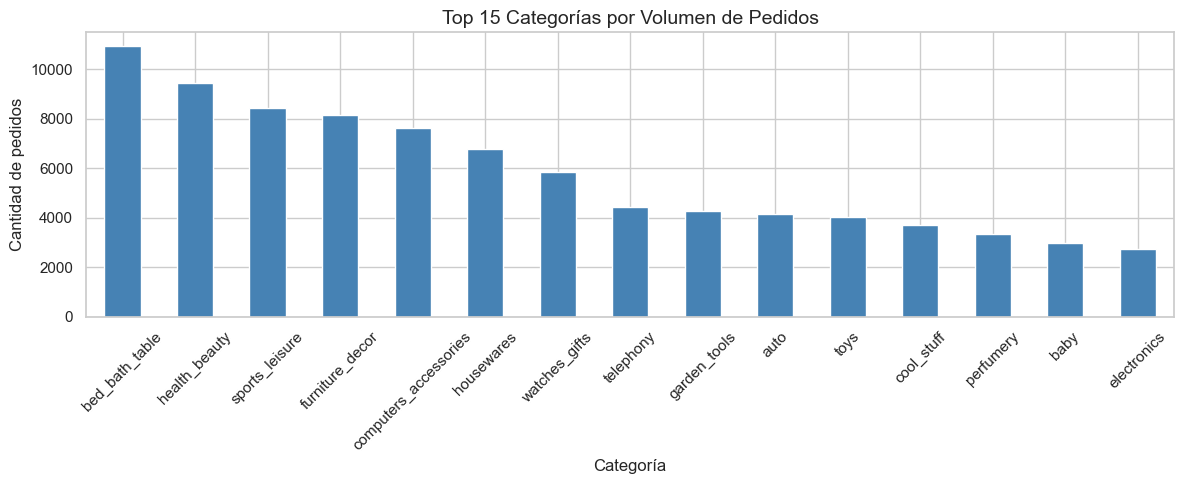

In [7]:
# Top 15 categorías por volumen de ventas
top_categories = (
    df.groupby('category')['order_id']
    .count()
    .sort_values(ascending=False)
    .head(15)
)

fig, ax = plt.subplots(figsize=(12, 5))
top_categories.plot(kind='bar', ax=ax, color='steelblue')
ax.set_title('Top 15 Categorías por Volumen de Pedidos', fontsize=14)
ax.set_xlabel('Categoría')
ax.set_ylabel('Cantidad de pedidos')
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.savefig('../docs/top_categories.png', dpi=150)
plt.show()

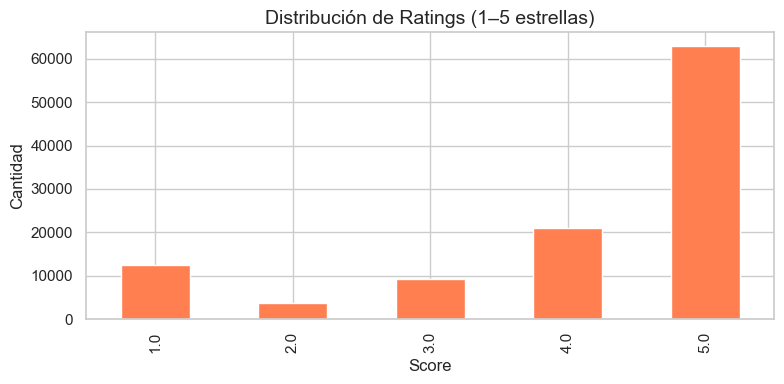


Rating promedio: 4.08
% de ratings >= 4: 76.3%


In [8]:
# Distribución de review scores
fig, ax = plt.subplots(figsize=(8, 4))
df['review_score'].value_counts().sort_index().plot(kind='bar', ax=ax, color='coral')
ax.set_title('Distribución de Ratings (1–5 estrellas)', fontsize=14)
ax.set_xlabel('Score')
ax.set_ylabel('Cantidad')
plt.tight_layout()
plt.savefig('../docs/review_distribution.png', dpi=150)
plt.show()

print(f"\nRating promedio: {df['review_score'].mean():.2f}")
print(f"% de ratings >= 4: {(df['review_score'] >= 4).mean()*100:.1f}%")

In [9]:
# Rating promedio por categoría
rating_by_cat = (
    df.groupby('category')['review_score']
    .agg(['mean', 'count'])
    .rename(columns={'mean': 'avg_rating', 'count': 'total_reviews'})
    .query('total_reviews >= 50')  # mínimo 50 reseñas para ser representativo
    .sort_values('avg_rating', ascending=False)
)

print('Top 10 categorías mejor valoradas:')
print(rating_by_cat.head(10))

print('\nTop 10 categorías peor valoradas:')
print(rating_by_cat.tail(10))

Top 10 categorías mejor valoradas:
                                       avg_rating  total_reviews
category                                                        
books_general_interest                   4.512195            533
books_imported                           4.508772             57
costruction_tools_tools                  4.444444             99
small_appliances_home_oven_and_coffee    4.438356             73
books_technical                          4.389313            262
food_drink                               4.364312            269
luggage_accessories                      4.352283           1073
fashion_shoes                            4.300395            253
cine_photo                               4.285714             70
food                                     4.262834            487

Top 10 categorías peor valoradas:
                       avg_rating  total_reviews
category                                        
home_construction        3.957770            592
fur

In [10]:
# Ticket promedio por categoría
avg_price_by_cat = (
    df.groupby('category')['price']
    .mean()
    .sort_values(ascending=False)
    .head(15)
)
print('Top 15 categorías por precio promedio:')
print(avg_price_by_cat)

Top 15 categorías por precio promedio:
category
computers                                        1098.915276
small_appliances_home_oven_and_coffee             638.213151
home_appliances_2                                 467.333117
agro_industry_and_commerce                        342.553883
musical_instruments                               283.127097
portateis_cozinha_e_preparadores_de_alimentos     280.973571
small_appliances                                  277.741824
fixed_telephony                                   216.922392
construction_tools_safety                         211.875519
watches_gifts                                     199.040276
furniture_bedroom                                 184.968932
air_conditioning                                  184.510588
kitchen_dining_laundry_garden_furniture           166.175109
cool_stuff                                        164.121598
pc_gamer                                          163.368750
Name: price, dtype: float64


## 5. Generación del dataset procesado para el RAG

Creamos un documento por producto con toda la información relevante. Estos documentos serán vectorizados en la Fase 2.

In [11]:
# Resumen por producto: métricas agregadas
product_summary = (
    df.groupby('product_id')
    .agg(
        category=('category', 'first'),
        total_orders=('order_id', 'count'),
        avg_price=('price', 'mean'),
        avg_rating=('review_score', 'mean'),
        total_reviews=('review_score', 'count'),
        positive_reviews=('review_score', lambda x: (x >= 4).sum()),
        sample_comment=('review_comment_message', lambda x: x.dropna().iloc[0] if x.dropna().shape[0] > 0 else '')
    )
    .reset_index()
)

product_summary['positive_rate'] = (
    product_summary['positive_reviews'] / product_summary['total_reviews']
).round(2)

product_summary['avg_price'] = product_summary['avg_price'].round(2)
product_summary['avg_rating'] = product_summary['avg_rating'].round(2)

print(f'Productos únicos: {len(product_summary):,}')
product_summary.head(3)

Productos únicos: 32,216


,product_id,category,total_orders,avg_price,avg_rating,total_reviews,positive_reviews,sample_comment,positive_rate
0,00066f42aeeb9f3007548bb9d3f33c38,perfumery,1,101.65,5.0,1,1,,1.0
1,00088930e925c41fd95ebfe695fd2655,auto,1,129.90,4.0,1,1,,1.0
2,0009406fd7479715e4bef61dd91f2462,bed_bath_table,1,229.00,1.0,1,0,Meu produto não foi entregue até o momento!,0.0


In [12]:
# Crear el campo 'document' — texto que será vectorizado en el RAG
def build_document(row):
    return (
        f"Product ID: {row['product_id']}. "
        f"Category: {row['category']}. "
        f"Average price: ${row['avg_price']}. "
        f"Average rating: {row['avg_rating']}/5 based on {row['total_reviews']} reviews. "
        f"Positive review rate: {row['positive_rate']*100:.0f}%. "
        f"Total orders: {row['total_orders']}. "
        f"Sample customer comment: '{row['sample_comment']}'"
    )

product_summary['document'] = product_summary.apply(build_document, axis=1)

print('Ejemplo de documento generado:')
print(product_summary['document'].iloc[0])

Ejemplo de documento generado:
Product ID: 00066f42aeeb9f3007548bb9d3f33c38. Category: perfumery. Average price: $101.65. Average rating: 5.0/5 based on 1 reviews. Positive review rate: 100%. Total orders: 1. Sample customer comment: ''


In [13]:
# Guardar dataset procesado
product_summary.to_csv(PROCESSED_PATH + 'product_summary.csv', index=False)

# También guardamos el dataset consolidado completo
df.to_csv(PROCESSED_PATH + 'orders_consolidated.csv', index=False)

print('✅ Datos procesados guardados en data/processed/')
print(f'   - product_summary.csv ({len(product_summary):,} productos)')
print(f'   - orders_consolidated.csv ({len(df):,} filas)')

✅ Datos procesados guardados en data/processed/
   - product_summary.csv (32,216 productos)
   - orders_consolidated.csv (110,197 filas)


## ✅ Resumen Fase 1

| Métrica | Valor |
|---------|-------|
| Órdenes entregadas | ~96.000 |
| Productos únicos | ~32.000 |
| Categorías | ~70 |
| Documentos generados para RAG | 1 por producto |

**Siguiente paso → Fase 2:** Vectorizar `product_summary['document']` con `sentence-transformers` e indexar en ChromaDB.